# 1) load the data and separate in X all the columns but the last one, in y the last column, then produce a pairplot of X and comment what you see

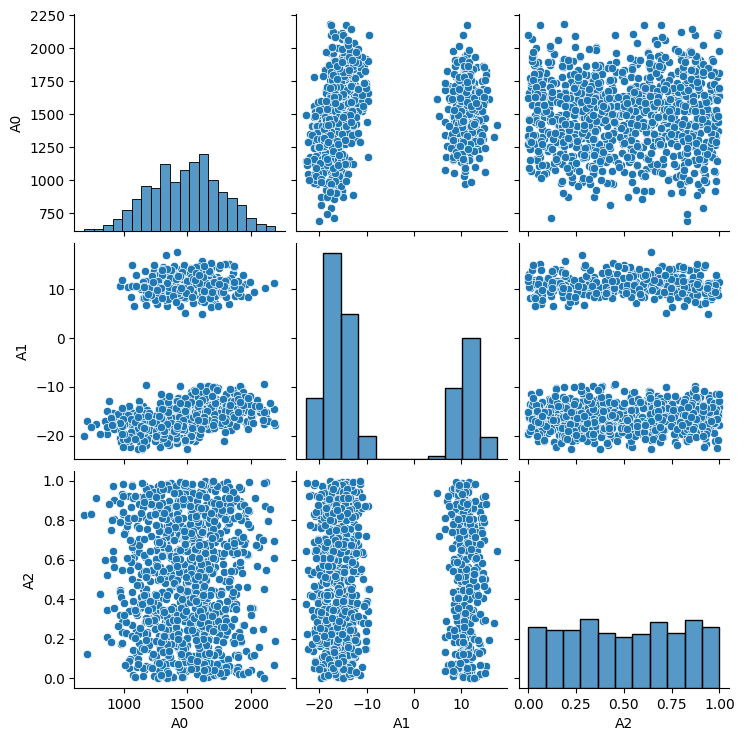

In [47]:
import pandas as pd

# Load the data
data = pd.read_csv("./exam_2021_01_15.csv")

# Separate X and y
X = data.iloc[:, :-1]
y = data.iloc[:,-1]

import seaborn as sns
import warnings 
warnings.filterwarnings("ignore")
sns.pairplot(X);

I see that A0 has a gaussian-like distribution, that A1 has 2 clearly separable clusters and that A2 has a uniform distribution.

In [48]:
X.describe()

,A0,A1,A2
count,1000.000000,1000.000000,1000.000000
mean,1489.096297,-7.166652,0.505010
std,274.553828,13.077564,0.293416
min,690.679955,-22.833984,0.000412
25%,1295.382256,-17.161708,0.246973
50%,1495.200642,-14.249017,0.518429
75%,1676.991938,9.600518,0.766703
max,2185.753771,17.595486,0.999833


# 2) find the best clustering schemefor X with a method of your choice, plot thesilhouhette index for an appropriate range of parameters and show the chosen hyperparameter(s) 
- consider carefully the number of clusters, simple optimisation of the silhouette will not be enough, decide visually the best number of clusters

In [49]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

random_state = 42
ks = [*range(2,11)]
silhouette_list = []
inertia_list = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=random_state)
    y_pred = model.fit_predict(X)
    silhouette_list.append(silhouette_score(X, y_pred))
    inertia_list.append(model.inertia_)

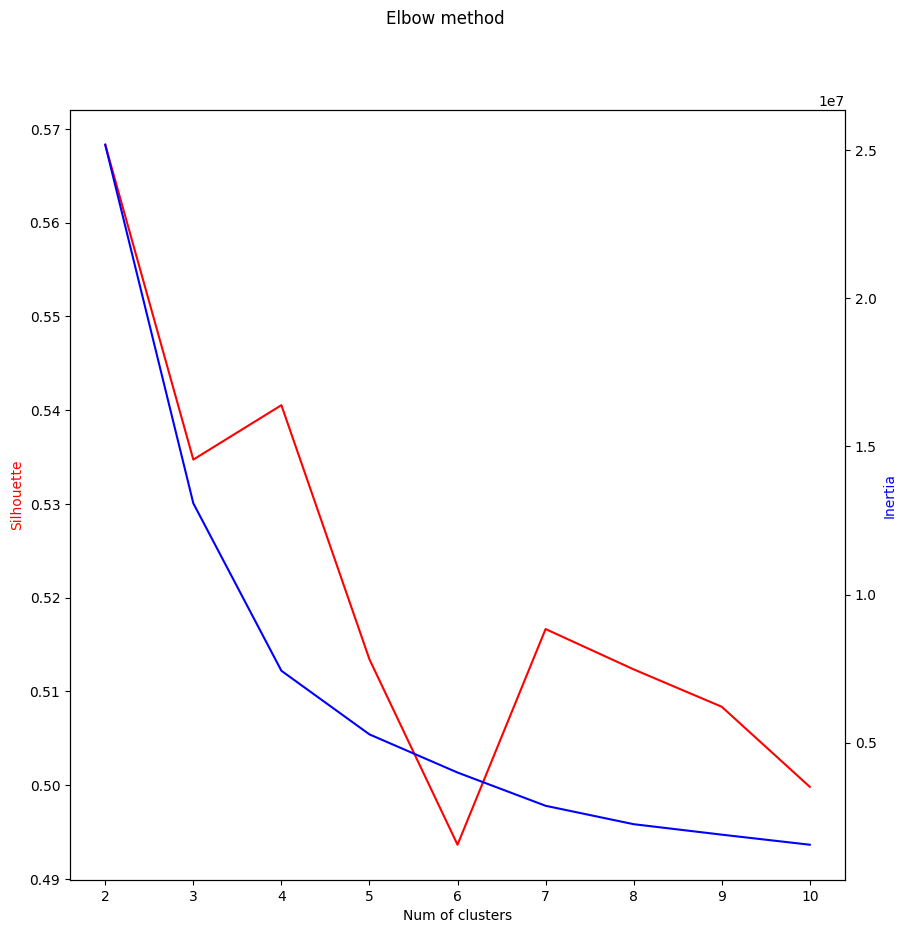

In [50]:
import matplotlib.pyplot as plt
 
fig, ax1 = plt.subplots(1,1,figsize=[10,10])
fig.suptitle("Elbow method")

color="r"
ax1.plot(ks, silhouette_list, c=color)
ax1.set_ylabel("Silhouette", c=color)
ax1.set_xlabel("Num of clusters")

color="b"
ax2 = ax1.twinx()
ax2.plot(ks, inertia_list, c=color)
ax2.set_ylabel("Inertia", c=color)

plt.show()

The elbow is in $K=4$ so we will consider 4 clusters as optimal.

PS: idk why but the optimal seems ti be $K=3$ form the true labels and we have to choose it in order to do next points...

# 3) fit the clustering scheme store the cluster labels in y_km and output the silhouette score

In [51]:
K = 3

best_km = KMeans(n_clusters=K, random_state=random_state)
y_km = best_km.fit_predict(X)

print(f"The silhouette score for the best clustering scheme is: {silhouette_score(X, y_km)}")

The silhouette score for the best clustering scheme is: 0.5347177935458868


# 4) Use the labels in the last column of the input file as the “gold standard”for the clustering and compare y_km and y; for an effective comparison, each label in y_km must be remapped to the best label in y; compute and apply this re-mapping(5pt)
- hint for each subset of the data with x in y_km find the most frequent label in y

In [52]:
X['y']=y
X['y_km']=y_km

X['remapped_lab']=y_km

for lab in X['y_km'].unique():

    subset=X[X['y_km']==lab]

    X['remapped_lab'][X['y_km']==lab]=subset['y'].mode().values[0]


# 5) produce the confusion matrix comparing y and y_km with sklearn.metrics.confusion_matrix,

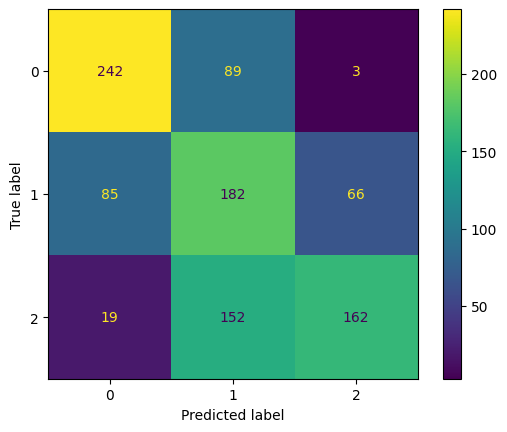

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
ConfusionMatrixDisplay(confusion_matrix(y, X['remapped_lab'])).plot();

# 6) consider possible pre-processing actions, repeat the fitting and evaluateas beforetheresultof the new fitting

In [54]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler

# Scale every attribute in the same range
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X.iloc[:,:3]), columns=scaler.get_feature_names_out())

In [55]:
X_scaled.describe()

,A0,A1,A2
count,1.000000e+03,1.000000e+03,1.000000e+03
mean,-9.023893e-16,-1.865175e-17,1.136868e-16
std,1.000500e+00,1.000500e+00,1.000500e+00
min,-2.909505e+00,-1.198631e+00,-1.720595e+00
25%,-7.059125e-01,-7.646728e-01,-8.798616e-01
50%,2.224482e-02,-5.418371e-01,4.575755e-02
75%,6.847097e-01,1.282774e+00,8.923289e-01
max,2.538686e+00,1.894430e+00,1.687262e+00


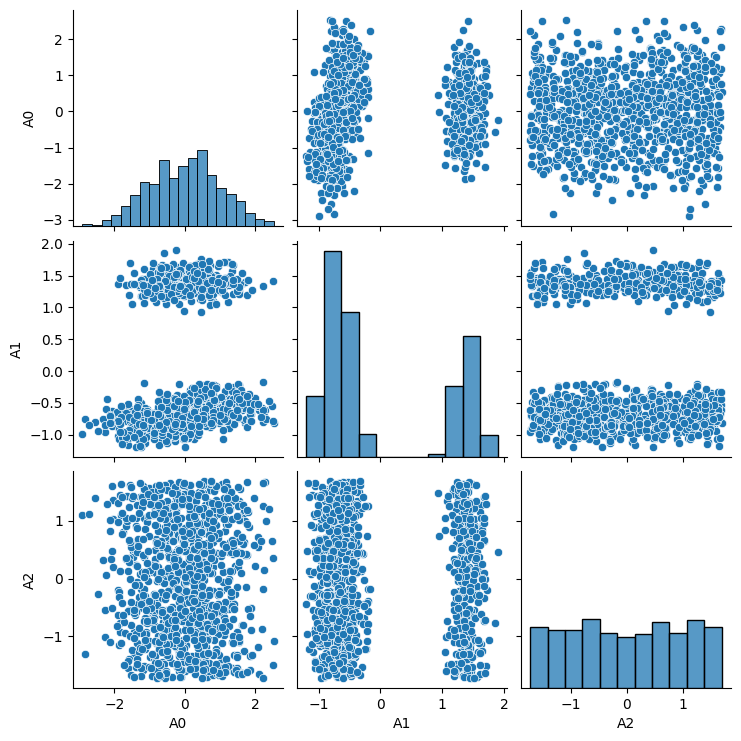

In [56]:
sns.pairplot(X_scaled);

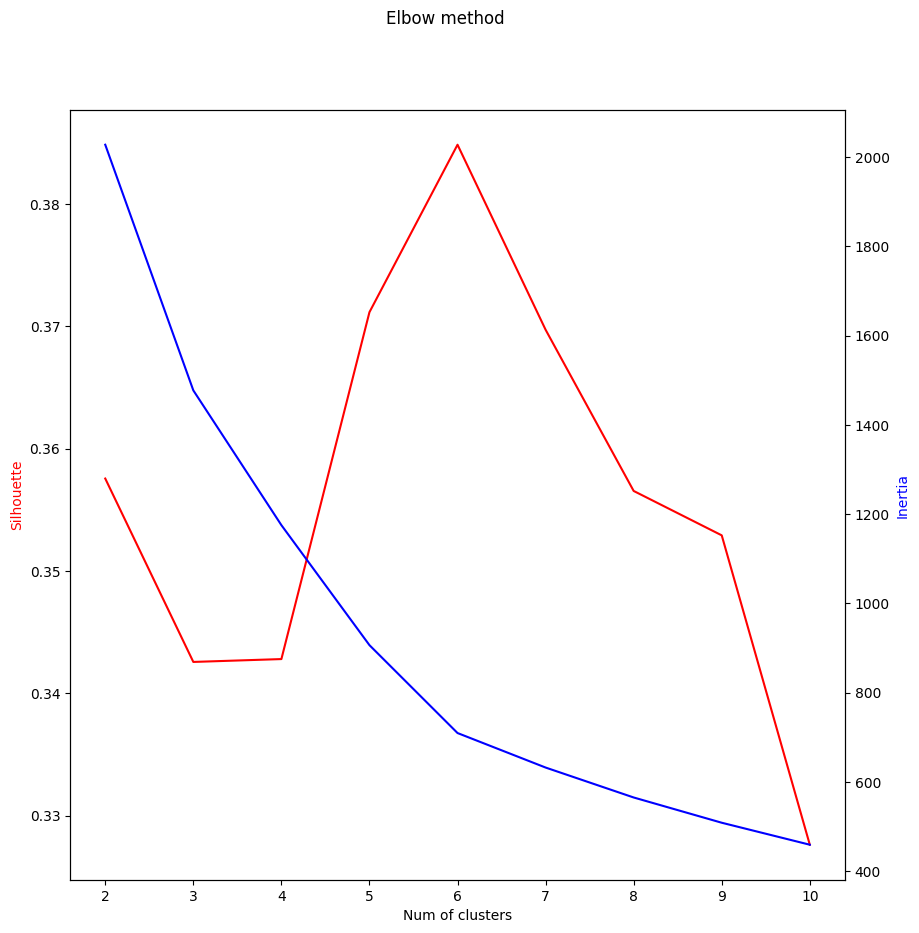

In [57]:
random_state = 42
ks = [*range(2,11)]
silhouette_list = []
inertia_list = []

for k in ks:
    model = KMeans(n_clusters=k, random_state=random_state)
    y_pred = model.fit_predict(X_scaled)
    silhouette_list.append(silhouette_score(X_scaled, y_pred))
    inertia_list.append(model.inertia_)
    
fig, ax1 = plt.subplots(1,1,figsize=[10,10])
fig.suptitle("Elbow method")

color="r"
ax1.plot(ks, silhouette_list, c=color)
ax1.set_ylabel("Silhouette", c=color)
ax1.set_xlabel("Num of clusters")

color="b"
ax2 = ax1.twinx()
ax2.plot(ks, inertia_list, c=color)
ax2.set_ylabel("Inertia", c=color)

plt.show()

In [58]:
K = 3

best_km = KMeans(n_clusters=K, random_state=random_state)
y_km = best_km.fit_predict(X_scaled)

print(f"The silhouette score for the best clustering scheme is: {silhouette_score(X, y_km)}")

The silhouette score for the best clustering scheme is: 0.14844520686818105


In [59]:
X_scaled['y']=y
X_scaled['y_km']=y_km

X_scaled['remapped_lab']=y_km

for lab in X_scaled['y_km'].unique():

    subset=X_scaled[X_scaled['y_km']==lab]

    X_scaled['remapped_lab'][X_scaled['y_km']==lab]=subset['y'].mode().values[0]



In [60]:
X_scaled['remapped_lab']

0      2
1      0
2      0
3      1
4      1
      ..
995    1
996    0
997    2
998    1
999    2
Name: remapped_lab, Length: 1000, dtype: int32

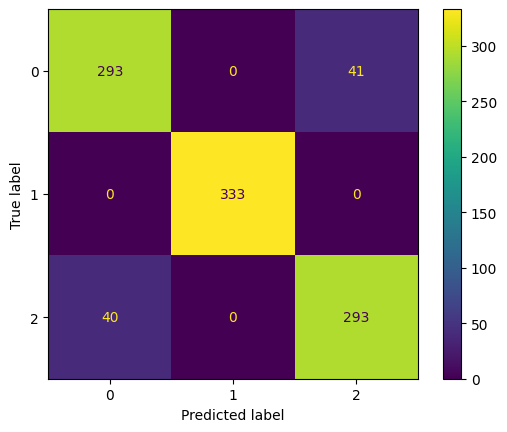

In [61]:
ConfusionMatrixDisplay(confusion_matrix(y, X_scaled['remapped_lab'])).plot();